In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import cartopy.crs as ccrs
import geopandas as gpd
#import rioxarray
import cartopy.feature as cf
#from rasterio.enums import Resampling


ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
# load precipitation station data
stations = ['Blenheim','Christchurch','Dunedin','Gisborne','Hamilton','Hokitika','Invercargill','Milford','Monowai','Napier',
           'Nelson','New Plymouth','Ngakuru','Palmerston North','Paraparaumu','Queenstown','Tauranga','Timaru','Wanganui',
           'Wellington','Whangarei']

df_list = []
for station in stations:
    df = pd.read_csv('/home/queenle/hydro_attribution/station_data/rainfall_21_series/'+station+'.csv')
    df['date'] = df['STATS_YEAR'].astype(str) + '-' + df['STATS_MONTH'].astype(str)
    df.index = pd.to_datetime(df['date'])
    ts = df['obs_value']
    ts = ts.rename(station)
    df_list.append(ts)

obs_df = pd.concat(df_list, axis=1)

# load station metadata
meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/rainfall_21_series/rainfall_stns.csv')
meta_df.loc[4,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell
meta_df.loc[5,'LONGT']=175.25 #slightly shift Napier so its nearest neighbor is not an ocean cell

In [24]:
obs_df

,Blenheim,Christchurch,Dunedin,Gisborne,Hamilton,Hokitika,Invercargill,Milford,Monowai,Napier,...,New Plymouth,Ngakuru,Palmerston North,Paraparaumu,Queenstown,Tauranga,Timaru,Wanganui,Wellington,Whangarei
date,,,,,,,,,,,,,,,,,,,,,
1951-01-01,56.0,99.2,80.4,143.4,97.5,85.6,54.1,144.0,93.0,74.1,...,64.7,92.6,73.4,34.0,44.9,204.5,131.4,67.7,85.1,107.3
1951-02-01,56.2,122.7,79.5,88.9,58.1,198.0,49.1,233.7,89.7,72.8,...,122.8,55.7,47.1,47.5,35.4,90.3,40.1,46.2,48.3,155.5
1951-03-01,81.5,110.9,67.6,111.9,20.9,152.7,84.0,332.8,87.4,70.9,...,78.2,61.2,49.8,74.1,30.2,23.4,76.3,55.8,136.8,48.2
1951-04-01,92.8,193.5,76.8,88.0,115.1,271.7,62.4,406.0,126.8,104.1,...,186.1,97.3,131.2,110.1,112.1,93.3,79.6,104.4,92.2,127.8
1951-05-01,60.5,61.9,73.8,136.6,90.4,174.2,95.9,261.1,82.9,97.1,...,102.2,69.0,56.6,46.8,89.4,130.5,6.6,103.7,119.3,76.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-01,61.2,16.6,38.0,56.0,97.6,306.8,101.1,-99.9,52.7,25.8,...,124.0,-99.9,40.0,73.2,58.4,-99.9,26.2,55.0,41.4,176.4
2020-09-01,-99.9,35.2,23.4,49.0,65.2,249.0,154.7,-99.9,222.5,62.2,...,118.2,-99.9,137.6,119.9,165.2,28.0,22.2,90.0,196.2,37.4
2020-10-01,32.4,29.2,49.8,46.2,50.0,391.0,160.0,-99.9,144.8,41.6,...,148.0,-99.9,63.0,76.1,74.6,23.8,25.2,59.8,102.4,82.2


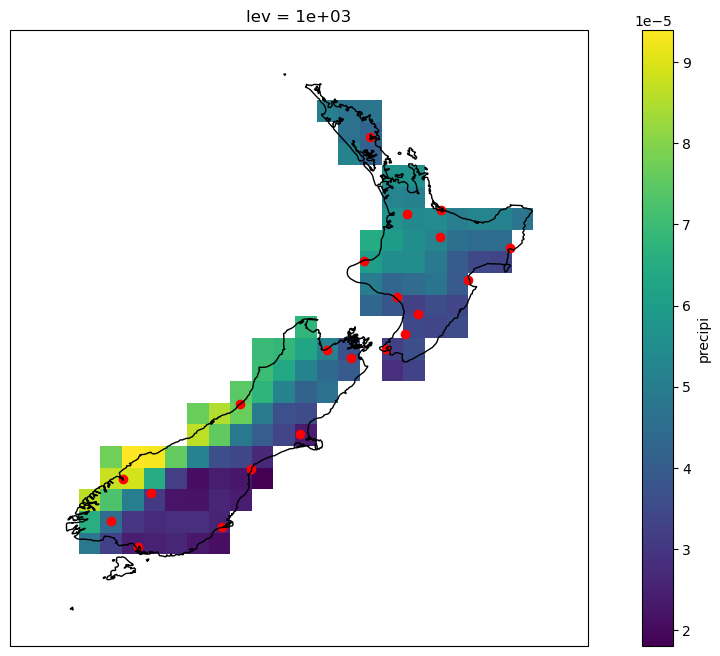

In [8]:
fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))


var = 'PRECIPI'
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/'


ens_mem_season = xr.open_dataarray(direc+var+"/full/means/PRECIPI_Amon_d4PDF_HPB_FullEnsMean_raw_winter_1951-2021.nc")
ens_mem_season.mean('time').plot(ax=axs)

lats = []
lons = []
for site in obs_df.columns:
    lat,lon = meta_df.loc[meta_df['station']==site][['LAT','LONGT']].values[0]
    lats.append(lat)
    lons.append(lon)
    ts = ens_mem_season.interp(lat=lat,lon=lon)
    #print(ts)


axs.coastlines()
axs.add_feature(cf.BORDERS)
axs.set_extent([165,180, -49,-33])#, crs=noproj)

axs.scatter(lons,lats,c='red')


In [4]:
lat,lon = meta_df.loc[meta_df['station']=='site'][['LAT','LONGT']].values[0]

ts = ens_mem_season.interp(lat=lat,lon=lon)
if np.isnan(ts).any():
    ts = ens_mem_season.interp(lat=lat,lon=lon,method='nearest')
    if np.isnan(ts).any():
        print(site)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [19]:
'''
Write ensemble member csv files with station-based PRECIPI time series
'''

def write_dataframe(direc,processing,var,scen,number,s):
    
    ens_mem_season = xr.open_dataarray(direc+var+'/full/'+var+'_Amon_d4PDF_'+scen+'_m'+number+'_'+processing+'_'+s+'_1951-2021.nc')
    
    df_dict = {'time':ens_mem_season.time.values}
    for site in obs_df.columns:
        lat,lon = meta_df.loc[meta_df['station']==site][['LAT','LONGT']].values[0]

        ts = ens_mem_season.interp(lat=lat,lon=lon)
        if np.isnan(ts).any():
            ts = ens_mem_season.interp(lat=lat,lon=lon,method='nearest')
            if np.isnan(ts).any():
                print(site)

        df_dict[site] = ts.values.flatten()

    df = pd.DataFrame(df_dict)
        
    df.to_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_"+processing+"_"+s+'_1951-2021.csv')

    
var = 'PRECIPI'
processing = 'raw'
direc = f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/{processing}/'

for scen in ['HPB','HPB_NAT']:

    print(scen)

    for s in ['winter','spring','summer','autumn']:
        print(s)

        for ens_mem in range(1,101):
            print(ens_mem)
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            write_dataframe(direc,processing,var,scen,number,s)
            

            

HPB
winter
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
spring
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
summer
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
autumn
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34

In [20]:
'''
write mean files
'''

processing = 'raw'
direc = f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/{processing}/'

for scen in ['HPB','HPB_NAT']:

    for s in ['winter','spring','summer','autumn']:

        dfs = []
        for ens_mem in range(1,101):
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            df = pd.read_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_"+processing+"_"+s+'_1951-2021.csv')

            df = df.set_index('time').drop('Unnamed: 0',axis=1)
            
            dfs.append(df)
        
            
        ens_mean_df = sum(dfs)/len(dfs)
        ens_mean_df.to_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_ensMean_'+processing+'_'+s+'_1951-2021.csv')

/home/queenle/.local/lib/python3.6/site-packages/pandas/plotting/_matplotlib/core.py:1192: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)


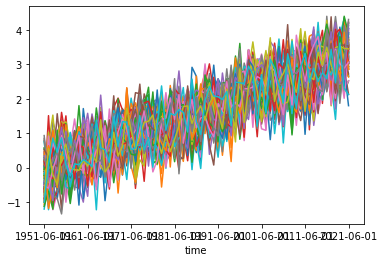

In [63]:
var = 'PRECIPI'
scen = 'HPB'
s = 'winter'

dfs = []
for ens_mem in range(1,101):

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    df = pd.read_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_gaussian_"+s+'_1951-2021.csv')

    df = df.set_index('time')#.drop('Unnamed: 0',axis=1)

    df.mean(axis=1).plot()
    
    dfs.append(df)

In [65]:
ens_mean_df

,Blenheim,Christchurch,Dunedin,Gisborne,Hamilton,Hokitika,Invercargill,Milford,Monowai,Napier,...,New Plymouth,Ngakuru,Palmerston North,Paraparaumu,Queenstown,Tauranga,Timaru,Wanganui,Wellington,Whangarei
time,,,,,,,,,,,,,,,,,,,,,
1951-03-01,-0.235252,0.028876,-0.169981,-0.044367,-0.131631,-0.336803,-0.137219,-0.329476,-0.261430,-0.003215,...,-0.233067,-0.221230,-0.113510,-0.152897,-0.266213,-0.134413,-0.014873,-0.125481,-0.055680,-0.161517
1952-03-01,-0.300979,-0.210759,-0.101657,-0.297916,-0.168651,0.154766,0.254006,0.108570,0.241728,-0.291310,...,-0.066116,-0.189791,-0.061018,-0.142068,0.086614,-0.234900,-0.285485,0.040159,-0.218867,-0.363891
1953-03-01,-0.262860,-0.320133,-0.120314,-0.379949,-0.254040,0.038833,-0.259956,0.038287,-0.226191,-0.323255,...,-0.193112,-0.297958,-0.232562,-0.235784,-0.147360,-0.274718,-0.195630,-0.213410,-0.227696,-0.371573
1954-03-01,0.034660,-0.005325,-0.037159,0.190537,0.164942,-0.063889,-0.233044,-0.169939,-0.177602,0.098817,...,0.251484,0.166079,0.051576,0.069028,-0.161551,0.165137,0.115487,0.125610,0.095341,0.333064
1955-03-01,0.439503,0.316380,0.140943,0.307760,0.407456,0.033453,-0.138922,-0.096055,-0.122946,0.256801,...,0.296596,0.377670,0.206358,0.284549,0.039274,0.415921,0.202402,0.160955,0.335250,0.508147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-03-01,-0.172952,-0.277070,-0.313461,-0.060260,-0.085845,-0.022333,-0.081679,0.100668,0.020280,-0.077997,...,-0.148812,-0.042291,-0.132917,-0.181261,-0.050213,-0.024889,-0.308187,-0.097367,-0.246915,-0.035347
2018-03-01,0.240995,0.339917,0.254762,0.381783,0.192826,-0.288025,-0.203561,-0.341695,-0.335729,0.379503,...,0.087645,0.175226,0.061249,0.066984,-0.269687,0.248660,0.306974,-0.022016,0.242136,0.343212
2019-03-01,-0.344965,-0.071464,0.120028,-0.280178,-0.087945,0.212796,0.583794,0.339066,0.569691,-0.220327,...,0.200341,-0.172414,0.076330,0.000826,0.390852,-0.232216,-0.087002,0.241453,-0.135435,-0.315440
